In [47]:
using Plots
using Revise
using DataInterpolations
using RegularizationTools

In [48]:
function read_custom_file(filepath::String)
    array1 = Float64[]
    array2 = Float64[]
    
    start_reading = false
    
    num_regex = r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?"

    open(filepath, "r") do file
        for line in eachline(file)

            clean_line = strip(line)

            if startswith(clean_line, "+") || startswith(clean_line, "-")
                matches = [m.match for m in eachmatch(num_regex, clean_line)]

                if length(matches) >= 2
                    push!(array1, parse(Float64, matches[1]))
                    push!(array2, parse(Float64, matches[2]))
                end
            else
                continue
            end
        end
    end
    return array1, array2
end

read_custom_file (generic function with 1 method)

In [49]:
cale = "/home/lali/TITAN-ROG-sync/julia/_Magnetism/S9279/S9279-FORC-100-2000-3s"
H_read = Float64[]
M_read = Float64[]
H_read, M_read = read_custom_file(cale*".txt")

([1966.098, 1986.494, 2006.154, 1925.957, 1965.76, 2005.98, 1885.728, 1926.528, 1966.719, 2005.959  …  1640.141, 1680.266, 1721.417, 1761.516, 1801.642, 1842.797, 1883.078, 1923.22, 1964.32, 2004.456], [0.000197773, 0.0001984672, 0.0001996092, 0.0001965595, 0.0001976215, 0.0001994341, 0.0001950355, 0.0001960298, 0.0001973349, 0.0001992555  …  0.0001700928, 0.0001720075, 0.0001755852, 0.0001770846, 0.0001799747, 0.0001826787, 0.0001843956, 0.0001864176, 0.0001884577, 0.0001898552])

In [50]:
#Normalize
normH = 1.0e3
normM = 1.0e-3
H_read = H_read ./ normH
M_read = M_read ./ normM
H_read, M_read

([1.966098, 1.986494, 2.006154, 1.9259570000000001, 1.96576, 2.00598, 1.885728, 1.926528, 1.966719, 2.0059590000000003  …  1.640141, 1.680266, 1.721417, 1.761516, 1.801642, 1.842797, 1.883078, 1.92322, 1.9643199999999998, 2.004456], [0.19777299999999998, 0.1984672, 0.1996092, 0.1965595, 0.19762149999999998, 0.1994341, 0.1950355, 0.19602979999999998, 0.1973349, 0.1992555  …  0.1700928, 0.17200749999999998, 0.1755852, 0.1770846, 0.1799747, 0.1826787, 0.1843956, 0.1864176, 0.1884577, 0.18985519999999997])

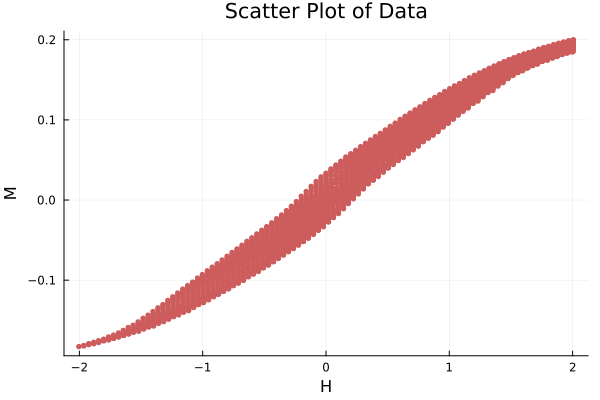

In [51]:
scatter(H_read, M_read, 
    title = "Scatter Plot of Data", 
    xlabel = "H", 
    ylabel = "M", 
    legend = false,   
    markersize = 3, 
    markercolor = :indianred,
    markerstrokecolor =:indianred
)

In [52]:
# Detect FORCs (Hr, numPointsPerFORC)
Hr_read = Float64[]
numPointsPerFORC = Int[]

current_Hr = H_read[1]
push!(Hr_read, current_Hr)

counterPointsPerFORC = 1

for i in 2:(length(H_read))
    if H_read[i] < H_read[i-1]
        global current_Hr = H_read[i]
        push!(numPointsPerFORC, counterPointsPerFORC)
        global counterPointsPerFORC = 0
    end
    global counterPointsPerFORC += 1
    push!(Hr_read, current_Hr)
end
push!(numPointsPerFORC, counterPointsPerFORC)
numFORCs = length(numPointsPerFORC)

println("----------- Total $(length(numPointsPerFORC)) FORCs -----------")
println("---------  $(numPointsPerFORC[1]) first / $(numPointsPerFORC[numFORCs]) last ---------")

----------- Total 100 FORCs -----------
---------  3 first / 100 last ---------


In [53]:
# Save Hr-H-M original file
n = length(Hr_read)
if length(H_read) != n || length(M_read) != n
    error("Error: All three arrays must have the same length.")
end

open(cale * "_Hr-H-M_orig.dat", "w") do file
    for i in 1:n
        println(file, "$(Hr_read[i])  $(H_read[i])  $(M_read[i])")
    end
end

In [54]:
function gimmeOneFORC(theFORC::Int64)
    contorNumPoints = 0
    H_interp = Float64[]
    M_interp = Float64[]
    #detect indexes for $(theFORC)
    if theFORC > 1
        for i in 1:theFORC-1
            contorNumPoints += numPointsPerFORC[i]
        end
    else
        contorNumPoints = 0
    end

    #myHr = Hr_read[contorNumPoints]
    startPointOnFORC = contorNumPoints + 1
    push!(H_interp, H_read[startPointOnFORC])
    push!(M_interp, M_read[startPointOnFORC])
    contorNumPoints = 1
    while (Hr_read[startPointOnFORC+contorNumPoints-1] - Hr_read[startPointOnFORC+contorNumPoints]) < 1.0e-5 #eps - compare floats
        push!(H_interp, H_read[startPointOnFORC+contorNumPoints])
        push!(M_interp, M_read[startPointOnFORC+contorNumPoints])
        contorNumPoints += 1
        if (startPointOnFORC + contorNumPoints) > length(Hr_read)
            break
        end
    end
    H_interp, M_interp
end

gimmeOneFORC (generic function with 1 method)

In [67]:
showTest = true

true

----------------- Interpolating Akima 100-th FORC ----------------


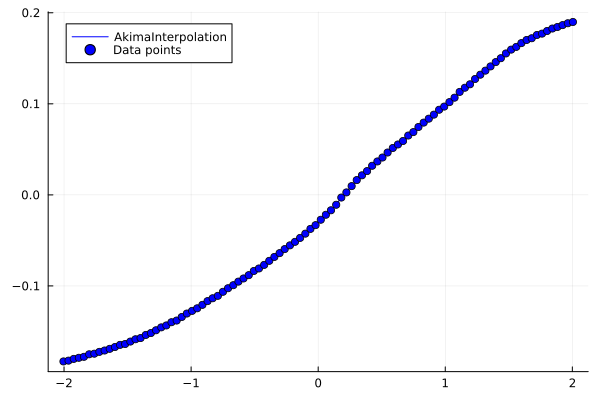

In [68]:
if (showTest)
    # Interpolate one FORC
    plotInterpFORC = 100 #div(numFORCs * 2, 3)
    println("----------------- Interpolating Akima $(plotInterpFORC)-th FORC ----------------")
    H_interp, M_interp = gimmeOneFORC(plotInterpFORC)
    Example = AkimaInterpolation(M_interp, H_interp)
    plot(Example)
end

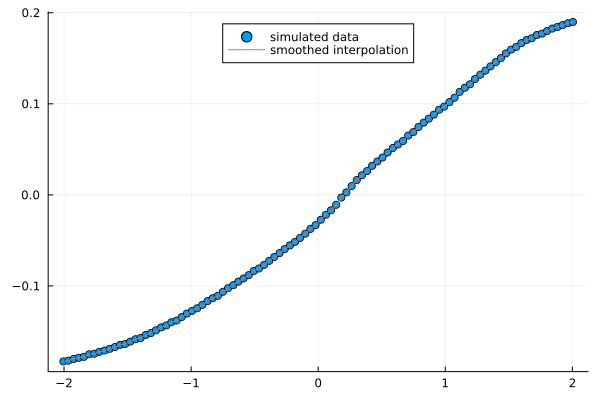

In [69]:
if (showTest)
    # Smooth one FORC (N - num points after smoothing)
    t, u = gimmeOneFORC(plotInterpFORC)
    d = 3
    A = RegularizationSmooth(u, t, d; alg=:gcv_svd)
    û = A.û
    N = plotInterpFORC #length(t)
    titp = collect(range(minimum(t), maximum(t), length=N))
    uitp = A.(titp)
    scatter(t, u, label="simulated data", legend=:top)
    plot!(titp, uitp, label="smoothed interpolation")
end

In [58]:
if (showTest)
    # Save interpolated / smoothed file for a single FORC
    nSmooth = length(titp)
    nOrig = length(H_interp)
    n = maximum([nSmooth, nOrig])

    open(cale * "_InterpSmoothCheck.dat", "w") do file
        for i in 1:n
            if (nSmooth >= nOrig)
                if (i <= nOrig)
                    println(file, "$(t[i]), $(u[i]), $(H_interp[i]), $(M_interp[i]), $(titp[i]), $(uitp[i])")
                else
                    println(file, "       ,        ,              ,                , $(titp[i]), $(uitp[i])")
                end
            else
                if (i <= nSmooth)
                    println(file, "$(t[i]), $(u[i]), $(H_interp[i]), $(M_interp[i]), $(titp[i]), $(uitp[i])")
                else
                    println(file, "$(t[i]), $(u[i]), $(H_interp[i]), $(M_interp[i]),           ,           ")
                end
            end
            
        end
    end
end

In [59]:
numFORCs = length(numPointsPerFORC) + 1 # +1 pentru one-point-FORC

M_NoExtend  = zeros(Float64, numFORCs, numFORCs) #matricea M
M_ExtendLine = zeros(Float64, numFORCs, numFORCs) #matricea M
M_ExtendMirror = zeros(Float64, numFORCs, numFORCs) #matricea M
Hr_NoExtend = zeros(Float64, numFORCs)
H_NoExtend  = zeros(Float64, numFORCs)

H, M = gimmeOneFORC(1)
Hr_NoExtend[1] = H[end]
H_NoExtend[numFORCs] = H[end]
M_NoExtend[1, numFORCs] = M[end]
M_ExtendLine[1, numFORCs] = M[end]
M_ExtendMirror[1, numFORCs] = M[end]
for i in 1:numFORCs-1
    M_ExtendLine[1, i] = M[end]
    M_ExtendMirror[1, i] = M[end]
end

for i in 2:numFORCs
    H, M = gimmeOneFORC(i-1)
    Hr_NoExtend[i] = H[begin]
    H_NoExtend[numFORCs-i+1] = H[begin]
end

In [ ]:
for i in 2:numFORCs
    t, u = gimmeOneFORC(i-1)
    if t[end] < Hr_NoExtend[1]
        t[end] = Hr_NoExtend[1]
    end

    #Example = AkimaInterpolation(M_interp, H_interp)

    d = 3
    A = RegularizationSmooth(u, t, d; alg=:gcv_svd)
    û = A.û
    N = i #length(t)
    titp = [Hr_NoExtend[j] for j=i:-1:1] #collect(range(minimum(t), maximum(t), length=N))
    uitp = A.(titp)
    #println("---------- $(i)/$(numFORCs) -------------")

    for j in 1:i
        M_NoExtend[i, numFORCs-i+j] = uitp[j]
        M_ExtendLine[i, numFORCs-i+j] = uitp[j]
        M_ExtendMirror[i, numFORCs-i+j] = uitp[j]
        #println(" $(M_NoExtend[i, numFORCs-i+j]) ")
    end
    for j in 1:numFORCs-i
        M_ExtendLine[i, j] = uitp[begin]
    end
    for j in numFORCs-i+1:-1:1
        if j+(2*(numFORCs-i+1-j)+1) <= numFORCs
            M_ExtendMirror[i, j] = M_ExtendMirror[i, j+(2*(numFORCs-i+1-j)+1)]
        else
            M_ExtendMirror[i, j] = uitp[end]
        end
    end

end

In [61]:
if (showTest)
    heatmap(M_ExtendMirror, yflip=true)
end

In [62]:
if (showTest)
        scatter(H_NoExtend, transpose(M_ExtendLine), legend=false,
                                                        markersize=3,
                                                        markercolor=:indianred,
                                                        markerstrokecolor=:indianred)
end

In [63]:
open(cale * ".MGRID.REGULAR.dat", "w") do file
    for i in 1:numFORCs
        for j in numFORCs-i+1:numFORCs
            println(file, "$(Hr_NoExtend[i])  $(H_NoExtend[j])  $(M_NoExtend[i, j])")
        end
        print(file, "\n")
    end
end

In [66]:
open(cale * ".MGRID.PrelungLine.dat", "w") do file
    for i in 1:numFORCs
        for j in 1:numFORCs
            println(file, "$(Hr_NoExtend[i])  $(H_NoExtend[j])  $(M_ExtendLine[i, j])")
        end
        print(file, "\n")
    end
end

In [65]:
SP = 4
FORC_NoExtend = zeros(Float64, numFORCs, numFORCs) #matricea FORC 
;